### This is a Data Analysis Notebook for the dataset 'House prediction Dataset'.
First we will be doing basic EDA 

In [1]:
# first lets import important libraries 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 


In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


as we can see there is not really any null values or missing values in the dataset .
Now however we can change the 'yes' and 'no' in :mainroad ,guestroom,basement ,hotwaterheating,airconditioning  into 0's and 1's since these are binbary values and for the model we would require numeric columns only 


before that lets plot some graphs for data analysis 

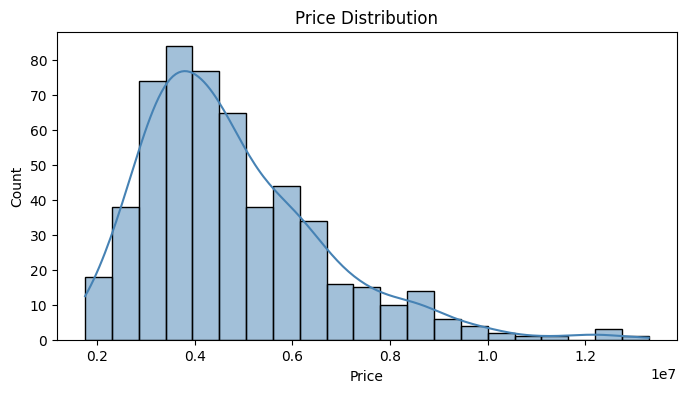

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

as we can see the majority of the houses have prices around 0.4 x 10 ^7

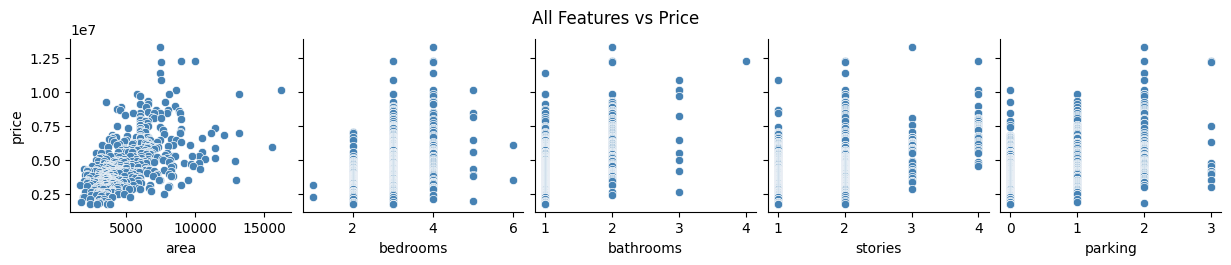

In [9]:
sns.pairplot(df, y_vars=['price'], 
             x_vars=['area', 'bedrooms', 'bathrooms', 'stories', 'parking'],
             plot_kws={'color': 'steelblue'})
plt.suptitle('All Features vs Price', y=1.02)
plt.show()


As we can have an insight that most number of houses have around 5000 sq feet as area ,3/4 bedrooms s the most common ,1/2 bathrooms,1/2 parking spots .
all these features comprise of the most number of houses .

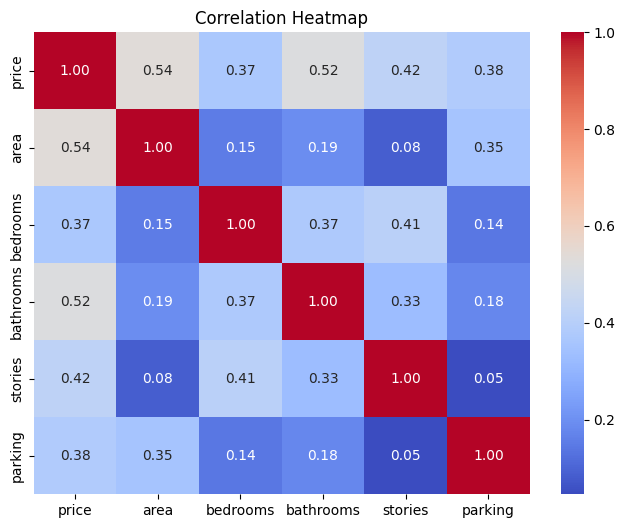

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['price','area','bedrooms','bathrooms','stories','parking']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Reading A corr heatmap 
there are various columns such as that of price ,area ,bedrooms ,bathrroms ,stories ,parking 
as we can see in the above map 
corr of price and area (i.e. 0.54) and corr of price and bathrooms (i.e. 0.52) is very high .
this depicts that area and bathrooms are important features in determining the price of the house .


Generally , features which have corr number with target variable less than 0.2 are tended to drop while creating the ML model .

But since all the features are around 0.3-0.5 all features are important .


### LABEL ENCODING 

Now as discussed earlier , before creating the prediction model we need to do some changes to the dataset i.e. changes the columns with yes and no into 0s and 1s ;and even the furniture column can be encoded 

This is called Binary Encoding or Label encoding 

In [11]:

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})

/var/folders/y6/rfzmqcx11v9c98r7x3chs72h0000gn/T/ipykernel_68007/1423753107.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'yes': 1, 'no': 0})


In [18]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


Now columns which have multiple categories we usse the method called one hot encoding instead of just replacing them with 0,1,2

In [19]:
from sklearn.preprocessing import OneHotEncoder

one = OneHotEncoder(sparse_output=False, drop='first')

encoded = one.fit_transform(df[['furnishingstatus']])

encoded_df = pd.DataFrame(encoded, columns=one.get_feature_names_out(['furnishingstatus']))

df = df.drop('furnishingstatus', axis=1)
df = pd.concat([df, encoded_df], axis=1)

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                              0.0                           0.0  
1                       

In [20]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0


### ML MODEL
now that we have created all numerical features in the dataset we can easily create the ML model

In [21]:
X = df.drop('price', axis=1)
y = df['price']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (436, 13)
Test size:  (109, 13)


In [32]:
# importing important stuff and libraries 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score


In [28]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(),
    'Lasso'             : Lasso(),
    'Random Forest'     : RandomForestRegressor(random_state=42),   
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)



In [29]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    print(name, "->", round(scores.mean(), 4), "±", round(scores.std(), 4))

Linear Regression -> 0.6324 ± 0.0737
Ridge -> 0.6334 ± 0.072
Lasso -> 0.6324 ± 0.0737
Random Forest -> 0.6182 ± 0.0562


# R^2 Evaluation Metrics 
we have used r^2 as the metrics of evaluation because this metrics is often used to tell how well the model has predicted for regression problems ;accuracy is more used in classification problems 

### HYperparameter tuning 

In [33]:
# ---- Ridge ----
ridge_params = {
    'alpha'   : [0.001, 0.01, 0.1, 1, 10, 50, 100, 200],
    'solver'  : ['auto', 'svd', 'cholesky', 'lsqr', 'saga'],
    'fit_intercept' : [True, False],
    'max_iter': [100, 500, 1000]
}
ridge_grid = GridSearchCV(Ridge(), ridge_params, 
                          cv=kf, scoring='r2')
ridge_grid.fit(X, y)
print(f"Best Ridge params    : {ridge_grid.best_params_}")
print(f"Best Ridge R²        : {ridge_grid.best_score_:.4f}\n")

# ---- Lasso ----
lasso_params = {
    'alpha'         : [0.001, 0.01, 0.1, 1, 10, 50, 100],
    'fit_intercept' : [True, False],
    'max_iter'      : [100, 500, 1000, 5000],
    'selection'     : ['cyclic', 'random'],
    'tol'           : [1e-4, 1e-3, 1e-2]
}
lasso_grid = GridSearchCV(Lasso(), lasso_params, 
                          cv=kf, scoring='r2')
lasso_grid.fit(X, y)
print(f"Best Lasso params    : {lasso_grid.best_params_}")
print(f"Best Lasso R²        : {lasso_grid.best_score_:.4f}\n")


# ---- Random Forest ----
rrf_params = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf'  : [1, 2, 4, 8],
    'max_features'      : ['sqrt', 'log2', None],
    'bootstrap'         : [True, False],
    'criterion'         : ['squared_error', 'absolute_error'],
    'max_leaf_nodes'    : [None, 10, 20, 50]
}
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=30,          # only 30 random combinations
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_random.fit(X, y)
print(f"Best RF params : {rf_random.best_params_}")
print(f"Best RF R²     : {rf_random.best_score_:.4f}\n")


/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/envs

Best Ridge params    : {'alpha': 10, 'fit_intercept': False, 'max_iter': 100, 'solver': 'auto'}
Best Ridge R²        : 0.6377



/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.116e+14, tolerance: 1.100e+12
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.394e+14, tolerance: 1.107e+12
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best Lasso params    : {'alpha': 1, 'fit_intercept': False, 'max_iter': 100, 'selection': 'random', 'tol': 0.001}
Best Lasso R²        : 0.6346

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/miniconda3/envs/jupyterenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.028e+14, tolerance: 1.429e+13
  model = cd_fast.enet_coordinate_descent(


Best RF params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_leaf_nodes': 50, 'max_features': 'log2', 'max_depth': None, 'criterion': 'squared_error', 'bootstrap': True}
Best RF R²     : 0.6476



AS we cansee Random Forest is the best model for this above problem and RF gives 0.64 value of r^2 . hence we chosse this model with its specififc parameters 

In [36]:
final_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=2,
    max_leaf_nodes=50,
    max_features='log2',
    max_depth=None,
    criterion='squared_error',
    bootstrap=True,
    random_state=42
)

final_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,50
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = final_model.predict(X_test)


results = pd.DataFrame({
    'Actual Price'    : y_test.values,
    'Predicted Price' : y_pred.round(0)
})

print(results.head(10))

   Actual Price  Predicted Price
0       4060000        5075877.0
1       6650000        6969083.0
2       3710000        3755652.0
3       6440000        4579540.0
4       2800000        3831791.0
5       4900000        3918738.0
6       5250000        5417076.0
7       4543000        5272577.0
8       2450000        3256821.0
9       3353000        3097741.0


In [41]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test,y_pred)

print(f"Final R²   : {r2:.4f}")
print(f"Final RMSE : ₹{rmse:,.0f}")

Final R²   : 0.6027
Final RMSE : ₹1,417,091


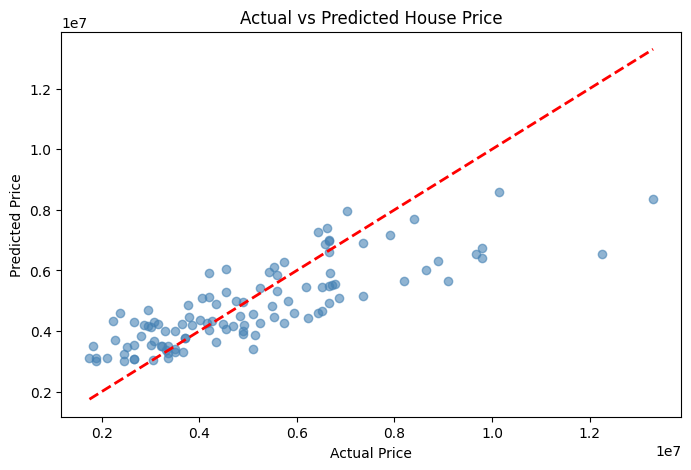

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Price')
plt.show()

### SOME FINAL INSIGHTS 
The model has an accuracy of 60 percent due to having only 513 rows .more data meant better training sets .

We can improve by doing some feature engineering like having a luxury column which is the cumulative of the sum of all the binary features (i.e. columns which have yes or no)

